In [1]:
# setup

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models
from tqdm import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Training on:", device)

Training on: cuda


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# data augmentation

train_transform = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

In [4]:
# datasets

train_data = datasets.ImageFolder("/content/drive/MyDrive/Data for Colab/aggregated_dataset/train", transform=train_transform)
val_data = datasets.ImageFolder("/content/drive/MyDrive/Data for Colab/aggregated_dataset/test", transform=val_transform)

train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
val_loader = DataLoader(val_data, batch_size=32)

num_classes = len(train_data.classes)
print("Classes:", train_data.classes)

Classes: ['Acne and Rosacea Photos', 'Actinic Keratosis Basal Cell Carcinoma and other Malignant Lesions', 'Atopic Dermatitis Photos', 'Bullous Disease Photos', 'Cellulitis Impetigo and other Bacterial Infections', 'Eczema Photos', 'Exanthems and Drug Eruptions', 'Hair Loss Photos Alopecia and other Hair Diseases', 'Herpes HPV and other STDs Photos', 'Light Diseases and Disorders of Pigmentation', 'Lupus and other Connective Tissue diseases', 'Melanoma Skin Cancer Nevi and Moles', 'Nail Fungus and other Nail Disease', 'Poison Ivy Photos and other Contact Dermatitis', 'Psoriasis pictures Lichen Planus and related diseases', 'Scabies Lyme Disease and other Infestations and Bites', 'Seborrheic Keratoses and other Benign Tumors', 'Squamous_Cell_Carcinoma', 'Systemic Disease', 'Tinea Ringworm Candidiasis and other Fungal Infections', 'Urticaria Hives', 'Vascular Tumors', 'Vasculitis Photos', 'Warts Molluscum and other Viral Infections']


In [5]:
# visualization imports
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter
from PIL import Image
import os

# for reproducibility in visualizations
np.random.seed(42)


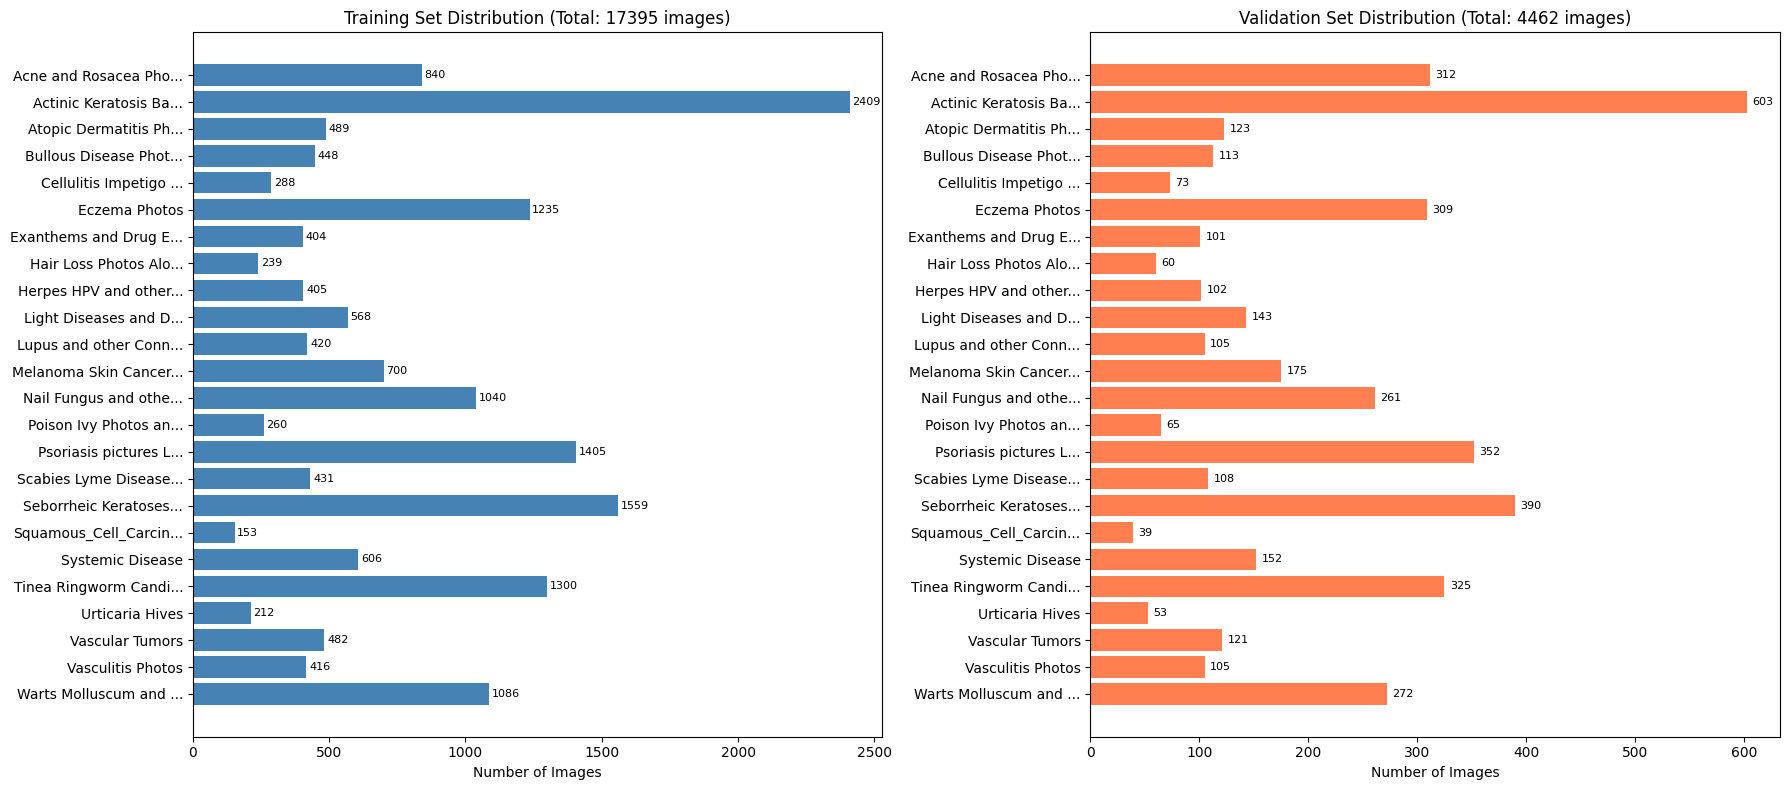


Class imbalance ratio (train): 15.75x


In [ ]:
# class distribution visualisation
class_counts_train = Counter([train_data.targets[i] for i in range(len(train_data))])
class_counts_val = Counter([val_data.targets[i] for i in range(len(val_data))])

class_names = train_data.classes
short_names = [name[:20] + '...' if len(name) > 20 else name for name in class_names]

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# training set distribution
train_counts = [class_counts_train[i] for i in range(len(class_names))]
bars1 = axes[0].barh(short_names, train_counts, color='steelblue')
axes[0].set_xlabel('Number of Images')
axes[0].set_title(f'Training Set Distribution (Total: {len(train_data)} images)')
axes[0].invert_yaxis()
for bar, count in zip(bars1, train_counts):
    axes[0].text(count + 10, bar.get_y() + bar.get_height()/2, str(count), va='center', fontsize=8)

# validation set distribution
val_counts = [class_counts_val[i] for i in range(len(class_names))]
bars2 = axes[1].barh(short_names, val_counts, color='coral')
axes[1].set_xlabel('Number of Images')
axes[1].set_title(f'Validation Set Distribution (Total: {len(val_data)} images)')
axes[1].invert_yaxis()
for bar, count in zip(bars2, val_counts):
    axes[1].text(count + 5, bar.get_y() + bar.get_height()/2, str(count), va='center', fontsize=8)

plt.tight_layout()
plt.show()

print(f"\nClass imbalance ratio (train): {max(train_counts)/min(train_counts):.2f}x")


In [7]:
# sample images from each class (1 per class)
# Create dataset without transforms to show original images
raw_train_data = datasets.ImageFolder("/content/drive/MyDrive/Data for Colab/aggregated_dataset/train")

n_classes = len(class_names)
cols = 5
rows = (n_classes + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(15, 3*rows))
axes = axes.flatten()

# Get one sample image per class
class_to_idx = {v: k for k, v in raw_train_data.class_to_idx.items()}
for class_idx in range(n_classes):
    # Find first image of this class
    for img_idx, (_, label) in enumerate(raw_train_data.samples):
        if label == class_idx:
            img_path = raw_train_data.samples[img_idx][0]
            img = Image.open(img_path).convert('RGB')
            axes[class_idx].imshow(img)
            axes[class_idx].set_title(short_names[class_idx], fontsize=8)
            axes[class_idx].axis('off')
            break

# Hide unused subplots
for idx in range(n_classes, len(axes)):
    axes[idx].axis('off')

plt.suptitle('Sample Images from Each Class', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


Output hidden; open in https://colab.research.google.com to view.

In [ ]:
# before and after data augmentation comparison
# define augmentation-only transform (no normalisation, for visualisation)
augment_only = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
])

# pick 4 random sample images
sample_indices = np.random.choice(len(raw_train_data), 4, replace=False)

fig, axes = plt.subplots(4, 5, figsize=(15, 12))

for row, idx in enumerate(sample_indices):
    img_path, label = raw_train_data.samples[idx]
    original_img = Image.open(img_path).convert('RGB')

    # show original
    axes[row, 0].imshow(original_img)
    axes[row, 0].set_title('Original' if row == 0 else '')
    axes[row, 0].axis('off')
    if row == 0:
        axes[row, 0].set_ylabel(short_names[label], fontsize=8)

    # show 4 augmented versions
    for col in range(1, 5):
        augmented_img = augment_only(original_img)
        axes[row, col].imshow(augmented_img)
        axes[row, col].set_title(f'Augmented {col}' if row == 0 else '')
        axes[row, col].axis('off')

plt.suptitle('Data Augmentation: Original vs Augmented Samples', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()


Output hidden; open in https://colab.research.google.com to view.

In [ ]:
# uses multiple workers to prefetch data in parallel and pins memory for faster GPU transfer

num_workers = 4  # 4 workers
prefetch_factor = 2  # 2 batches to prefetch per worker

train_loader = DataLoader(
    train_data,
    batch_size=32,
    shuffle=True,
    num_workers=num_workers,
    pin_memory=True,
    persistent_workers=True,
    prefetch_factor=prefetch_factor
)

val_loader = DataLoader(
    val_data,
    batch_size=32,
    num_workers=num_workers,
    pin_memory=True,
    persistent_workers=True,
    prefetch_factor=prefetch_factor
)

# Warm up the data loaders by iterating once (caches files from Google Drive)
print("Warming up data loaders (this caches files from Google Drive)...")
for _ in tqdm(train_loader, desc="Caching train data"):
    pass
for _ in tqdm(val_loader, desc="Caching val data"):
    pass
print("Data loaders warmed up! Subsequent epochs will be fast.")


Warming up data loaders (this caches files from Google Drive)...


Caching val data: 100%|██████████| 140/140 [11:59<00:00,  5.14s/it]

Data loaders warmed up! Subsequent epochs will be fast.


In [ ]:
# model (ResNet50)
model = models.resnet50(pretrained=True)

# freeze backbone except last block (layer4) - similar to EfficientNet-B3's approach
# ResNet50 structure: conv1 -> bn1 -> layer1 -> layer2 -> layer3 -> layer4 -> avgpool -> fc
# unfreezing layer4 and fc (classifier) for fine-tuning here
for name, param in model.named_parameters():
    if "layer4" not in name and "fc" not in name:
        param.requires_grad = False

# replace classifier head
model.fc = nn.Linear(model.fc.in_features, num_classes)
model = model.to(device)

# print trainable parameters info
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,} ({100*trainable_params/total_params:.1f}%)")

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 212MB/s]


Total parameters: 23,557,208
Trainable parameters: 15,013,912 (63.7%)


In [ ]:
# loss + optimisation (matched to EfficientNet-B3 hyperparameters for fair comparison)
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=0.0005)

# scheduler: reduce learning rate if validation loss stays the same or higher for 2 epochs
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=2, factor=0.5)

In [ ]:
# train + validation
# history tracking for plotting curves
history = {
    'train_loss': [], 'train_acc': [],
    'val_loss': [], 'val_acc': []
}

num_epochs = 15  # shared with EfficientNet-B3 for fair comparison
for epoch in range(num_epochs):
    model.train()
    running_loss, running_corrects = 0.0, 0
    for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}"):
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        _, preds = torch.max(outputs, 1)
        running_loss += loss.item() * images.size(0)
        running_corrects += torch.sum(preds == labels)

    epoch_loss = running_loss / len(train_data)
    epoch_acc = (running_corrects.double() / len(train_data)).item()

    model.eval()
    val_loss, val_corrects = 0.0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            _, preds = torch.max(outputs, 1)
            val_loss += loss.item() * images.size(0)
            val_corrects += torch.sum(preds == labels)

    val_loss /= len(val_data)
    val_acc = (val_corrects.double() / len(val_data)).item()

    # track history using a dictionary
    history['train_loss'].append(epoch_loss)
    history['train_acc'].append(epoch_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

    scheduler.step(val_loss)

    print(f"Epoch {epoch+1}/{num_epochs} "
          f"- Train Loss: {epoch_loss:.4f}, Train Acc: {epoch_acc:.4f} "
          f"- Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")

Epoch 1/15: 100%|██████████| 544/544 [01:43<00:00,  5.26it/s]


Epoch 1/15 - Train Loss: 2.2426, Train Acc: 0.3394 - Val Loss: 2.0698, Val Acc: 0.3873


Epoch 2/15: 100%|██████████| 544/544 [01:42<00:00,  5.29it/s]


Epoch 2/15 - Train Loss: 1.9214, Train Acc: 0.4256 - Val Loss: 1.8644, Val Acc: 0.4487


Epoch 3/15: 100%|██████████| 544/544 [01:40<00:00,  5.42it/s]


...

Epoch 13/15 - Train Loss: 0.8150, Train Acc: 0.7384 - Val Loss: 1.5616, Val Acc: 0.5834


Epoch 14/15: 100%|██████████| 544/544 [01:41<00:00,  5.39it/s]


Epoch 14/15 - Train Loss: 0.7609, Train Acc: 0.7533 - Val Loss: 1.5902, Val Acc: 0.5928


Epoch 15/15: 100%|██████████| 544/544 [01:42<00:00,  5.28it/s]


Epoch 15/15 - Train Loss: 0.7156, Train Acc: 0.7660 - Val Loss: 1.6350, Val Acc: 0.5946


In [13]:
# save model
torch.save(model.state_dict(), "aggregated_resnet50.pth")

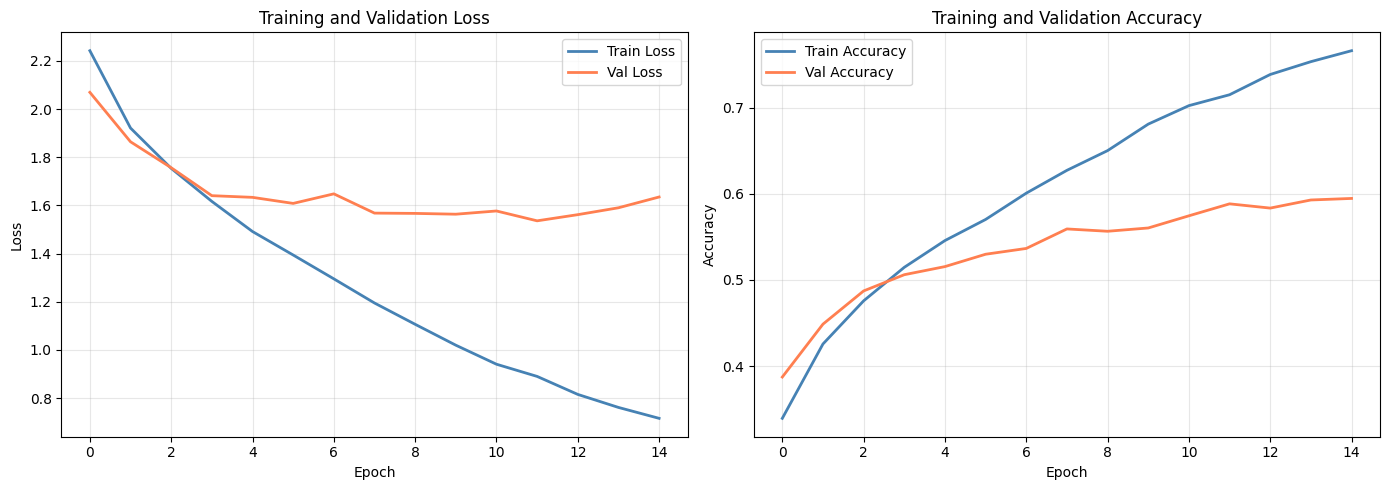

Best validation accuracy: 0.5946 at epoch 15
Final validation accuracy: 0.5946


In [ ]:
# training curves - loss and accuracy over epochs
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# loss curve
axes[0].plot(history['train_loss'], label='Train Loss', color='steelblue', linewidth=2)
axes[0].plot(history['val_loss'], label='Val Loss', color='coral', linewidth=2)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training and Validation Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# accuracy curve
axes[1].plot(history['train_acc'], label='Train Accuracy', color='steelblue', linewidth=2)
axes[1].plot(history['val_acc'], label='Val Accuracy', color='coral', linewidth=2)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Training and Validation Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Best validation accuracy: {max(history['val_acc']):.4f} at epoch {history['val_acc'].index(max(history['val_acc'])) + 1}")
print(f"Final validation accuracy: {history['val_acc'][-1]:.4f}")


In [15]:
# model evaluation - get predictions on validation set
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in tqdm(val_loader, desc="Evaluating"):
        images = images.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)


Evaluating: 100%|██████████| 140/140 [00:19<00:00,  7.15it/s]


In [16]:
# classification report - precision, recall, F1-score for each class
print("Classification Report")
print("=" * 80)
print(classification_report(all_labels, all_preds, target_names=short_names, digits=4))


Classification Report
                         precision    recall  f1-score   support

Acne and Rosacea Pho...     0.8482    0.8237    0.8358       312
Actinic Keratosis Ba...     0.7550    0.7463    0.7506       603
Atopic Dermatitis Ph...     0.6162    0.4959    0.5495       123
Bullous Disease Phot...     0.6250    0.3540    0.4520       113
Cellulitis Impetigo ...     0.3833    0.3151    0.3459        73
          Eczema Photos     0.6568    0.5761    0.6138       309
Exanthems and Drug E...     0.4327    0.4455    0.4390       101
Hair Loss Photos Alo...     0.5645    0.5833    0.5738        60
Herpes HPV and other...     0.4483    0.3824    0.4127       102
Light Diseases and D...     0.4503    0.4755    0.4626       143
Lupus and other Conn...     0.2500    0.5905    0.3513       105
Melanoma Skin Cancer...     0.6647    0.6343    0.6491       175
Nail Fungus and othe...     0.7456    0.8084    0.7757       261
Poison Ivy Photos an...     0.5435    0.3846    0.4505        65
Ps

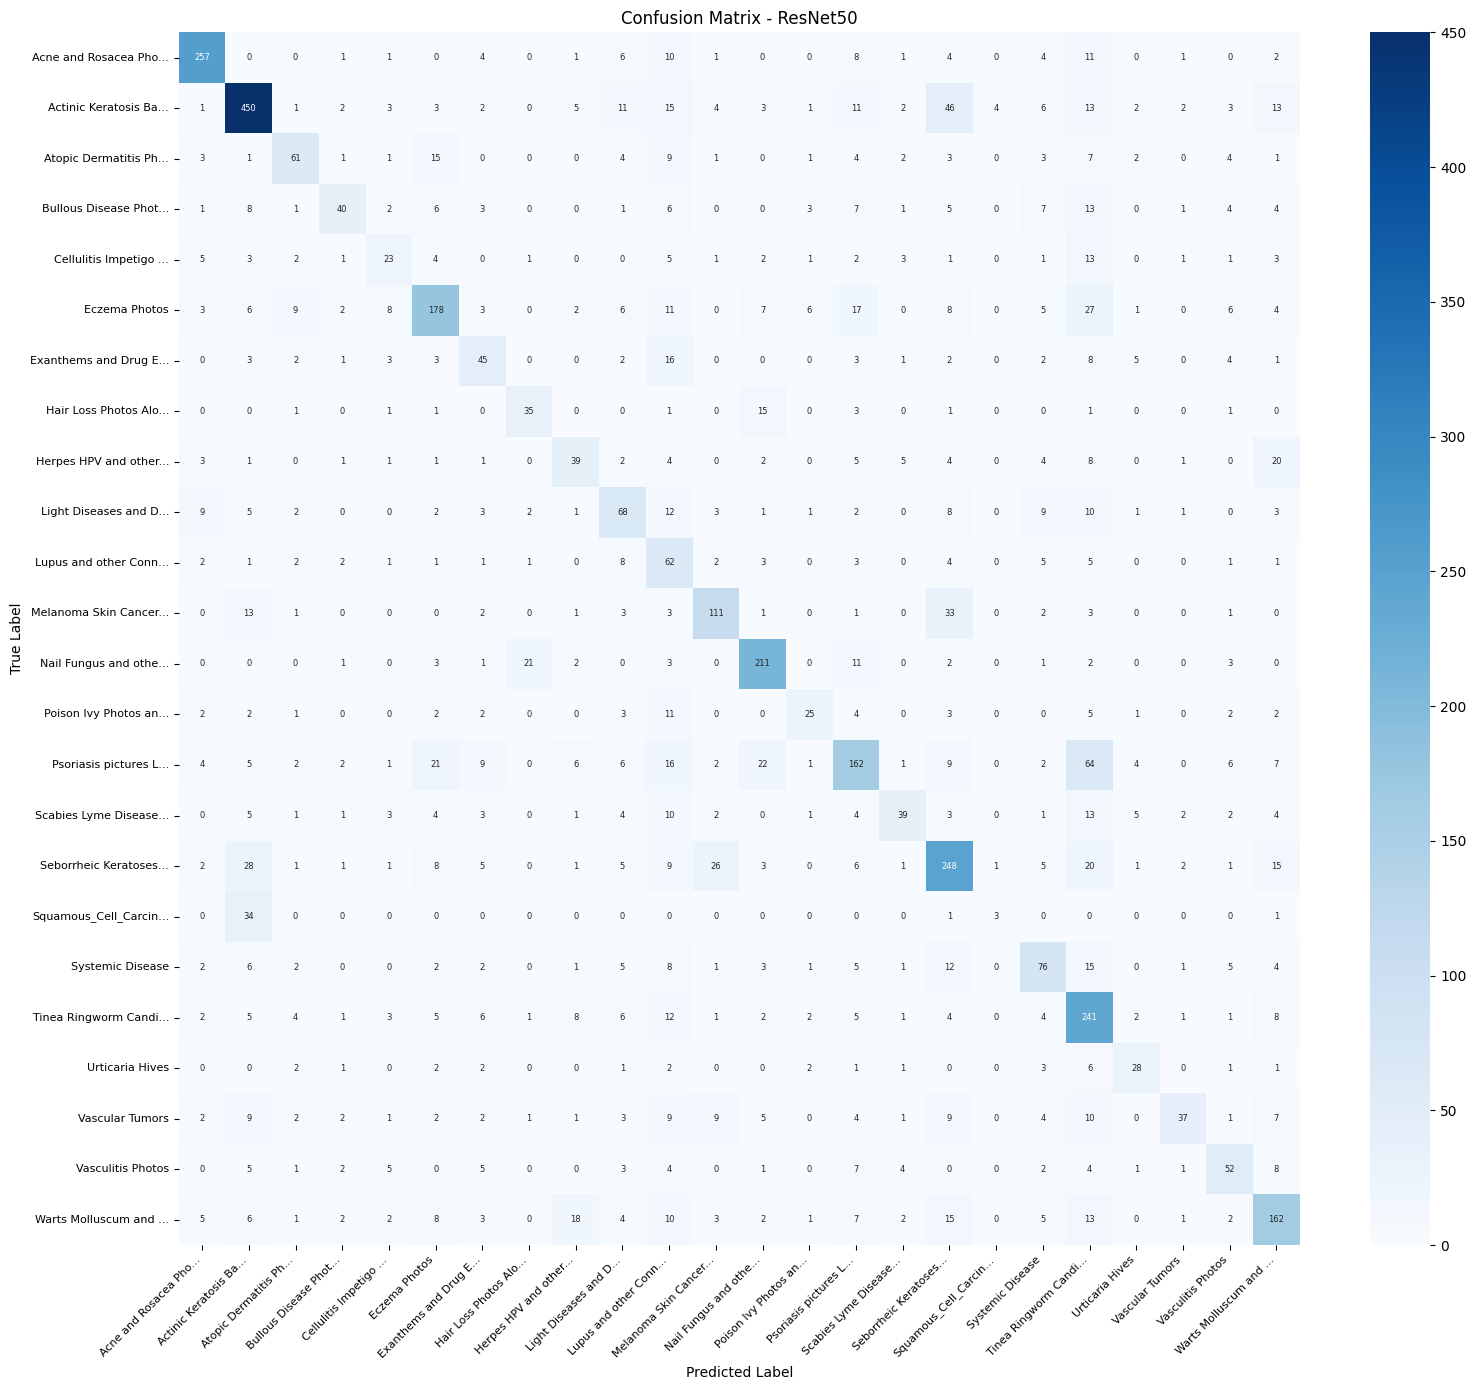


Overall Accuracy: 0.5946 (59.46%)


In [ ]:
# confusion matrix visualisation
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(16, 14))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=short_names, yticklabels=short_names,
            annot_kws={'size': 6})
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - ResNet50')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.show()

# overall accuracy
accuracy = np.sum(np.diag(cm)) / np.sum(cm)
print(f"\nOverall Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")


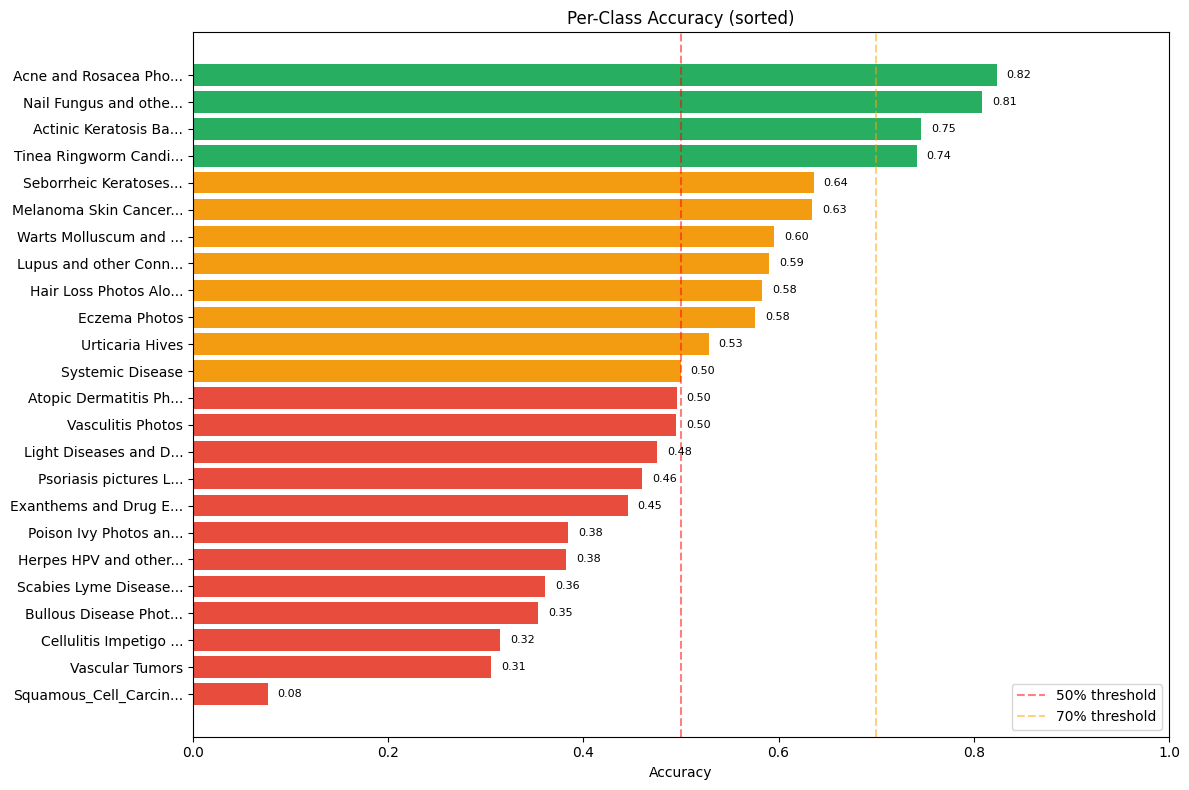


Best performing classes:
  Acne and Rosacea Photos: 0.8237
  Nail Fungus and other Nail Disease: 0.8084
  Actinic Keratosis Basal Cell Carcinoma and other Malignant Lesions: 0.7463

Worst performing classes:
  Squamous_Cell_Carcinoma: 0.0769
  Vascular Tumors: 0.3058
  Cellulitis Impetigo and other Bacterial Infections: 0.3151


In [ ]:
# per-class accuracy analysis
per_class_acc = cm.diagonal() / cm.sum(axis=1)
sorted_indices = np.argsort(per_class_acc)

# plot per-class accuracy
fig, ax = plt.subplots(figsize=(12, 8))
colors = ['#e74c3c' if acc < 0.5 else '#f39c12' if acc < 0.7 else '#27ae60' for acc in per_class_acc[sorted_indices]]
bars = ax.barh([short_names[i] for i in sorted_indices], per_class_acc[sorted_indices], color=colors)
ax.set_xlabel('Accuracy')
ax.set_title('Per-Class Accuracy (sorted)')
ax.set_xlim(0, 1)
ax.axvline(x=0.5, color='red', linestyle='--', alpha=0.5, label='50% threshold')
ax.axvline(x=0.7, color='orange', linestyle='--', alpha=0.5, label='70% threshold')
ax.legend()

# add accuracy values on bars
for bar, acc in zip(bars, per_class_acc[sorted_indices]):
    ax.text(acc + 0.01, bar.get_y() + bar.get_height()/2, f'{acc:.2f}', va='center', fontsize=8)

plt.tight_layout()
plt.show()

# print best and worst performing classes
print(f"\nBest performing classes:")
for i in sorted_indices[-3:][::-1]:
    print(f"  {class_names[i]}: {per_class_acc[i]:.4f}")
print(f"\nWorst performing classes:")
for i in sorted_indices[:3]:
    print(f"  {class_names[i]}: {per_class_acc[i]:.4f}")
